1\. **Kernel Density Estimate**

Produce a KDE for a given distribution (by hand, not using seaborn!):

* Fill a numpy array, x,  of len(N) (with N=O(100)) with a variable normally distributed, with a given mean a standard deviation
* Fill an histogram in pyplot taking properly care about the aesthetic
   * use a meaningful number of bins
   * set a proper y axis label
   * set proper value of y axis major ticks labels (e.g. you want to display only integer labels)
   * display the histograms as data points with errors (the error being the poisson uncertainty)
* for every element of x, create a gaussian with the mean corresponding the element value and std as a parameter that can be tuned. The std default value should be:
$$ 1.06 * x.std() * x.size ^{-\frac{1}{5.}} $$
you can use the scipy function `stats.norm()` for that.
* In a separate plot (to be placed beside the original histogram), plot all the gaussian functions so obtained
* Sum (with np.sum()) all the gaussian functions and normalize the result such that the integral matches the integral of the original histogram. For that you could use the `scipy.integrate.trapz()` method


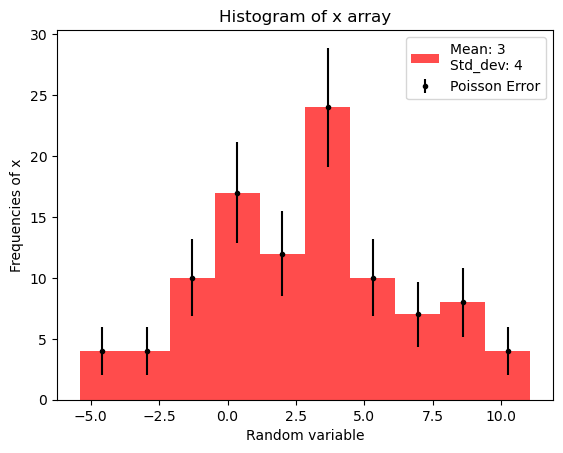

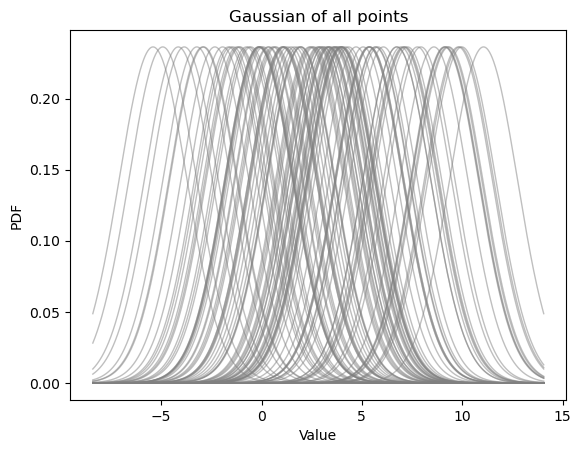

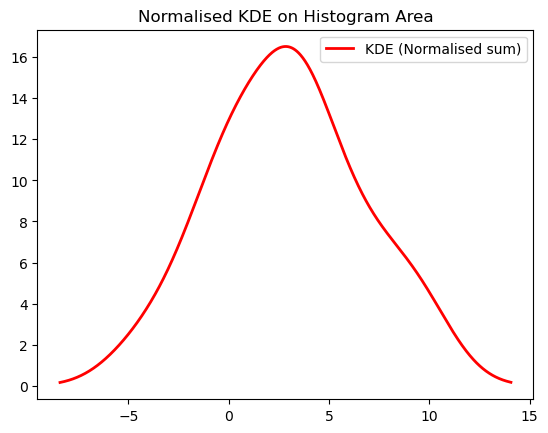

In [83]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp

# Insert mean, variance and fill x
mean = 3
dev_std = 4
x = np.random.normal(mean, dev_std, 100)

# Fill an histogram in pyplot
fig, ax = plt.subplots()
legend_label = f"Mean: {mean} \nStd_dev: {dev_std}"
counts, bins, _ = ax.hist(x, bins=int(np.sqrt(len(x))), label=legend_label, alpha=0.7, color='red')
bin_center = 0.5 * (bins[1:] + bins[:-1])
errors = np.sqrt(counts)
ax.errorbar(bin_center, counts, yerr=errors, fmt='.', color='black', label='Poisson Error')

# Format the histogram nicely
ax.set_title("Histogram of x array")
ax.set_xlabel("Random variable")
ax.set_ylabel("Frequencies of x")
ax.legend()
plt.show()


# Produce a KDE
gaussians_devstd = 1.06 * dev_std * len(x) ** (-1/5)    # Standard value, can be changed
gauss = [sp.stats.norm(x, gaussians_devstd) for x in x]

fig1, ax1 = plt.subplots()
x_plot = np.linspace(x.min() - 3, x.max() + 3, 1000)
for g in gauss:
    ax1.plot(x_plot, g.pdf(x_plot), color='grey', alpha=0.5, linewidth=1)

ax1.set_xlabel("Value")
ax1.set_ylabel("PDF")
ax1.set_title("Gaussian of all points")
plt.show()


# Sum and normalise the integral
all_pdfs = [g.pdf(x_plot) for g in gauss]
sum_kde = np.sum(all_pdfs, axis=0)

area_kde = sp.integrate.trapezoid(sum_kde, x_plot)
bin_widths = np.diff(bins) # Larghezza di ogni bin
area_hist = np.sum(counts * bin_widths)

fig2, ax2 = plt.subplots()
scaling_factor = area_hist / area_kde
final_curve = sum_kde * scaling_factor
ax2.plot(x_plot, final_curve, color='red', linewidth=2, label='KDE (Normalised sum)')
ax2.set_title(f"Normalised KDE on Histogram Area")
ax2.legend()
plt.show()

2\. **Color-coded scatter plot**

Produce a scatter plot out of a dataset with two categories

* Write a function that generate a 2D datasets of 2 categories. Each category should distribute as a 2D gaussian with a given mean and std (clearly it is better to have different values means..)
* Display the dataset in a scatter plot marking the two categories with different marker colors.

An example is given below

You can try to make the procedure more general by allowing a given number $n\ge 2$ of categories

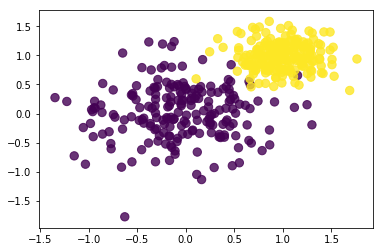

In [73]:
#! wget2 https://www.dropbox.com/s/u4y3k4kk5tc7j46/two_categories_scatter_plot.png
from IPython.display import Image
Image('two_categories_scatter_plot.png')

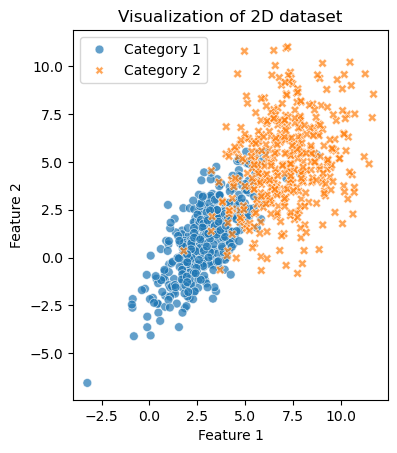

In [6]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

def generate_dataset(n_points, mean1, std1, mean2, std2):
    cov1 = np.array(std1).reshape(2,2)
    cov2 = np.array(std2).reshape(2,2)
    
    # First category
    data1 = np.random.multivariate_normal(mean1, cov1, n_points)
    df1 = pd.DataFrame(data1, columns=['X', 'Y'])
    df1['Category'] = 'Category 1'

    # Second category
    data2 = np.random.multivariate_normal(mean2, cov2, n_points)
    df2 = pd.DataFrame(data2, columns=['X', 'Y'])
    df2['Category'] = 'Category 2'

    return pd.concat([df1, df2], ignore_index=True)


mean1 = (3, 1)
std1 = (2, 2, 2, 4)
mean2 = (7, 5)
std2 = (3, 1, 1, 5)
df = generate_dataset(400, mean1, std1, mean2, std2)

sns.scatterplot(
    data=df, 
    x='X', 
    y='Y', 
    hue='Category', 
    style='Category', 
    s=40,
    alpha=0.7 
)

plt.title(f'Visualization of 2D dataset')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.gca().set_aspect('equal', adjustable='box')     # Same scale for X and Y
plt.show()

3\. **Profile plot**

Produce a profile plot from a scatter plot.
* Download the following dataset and load it as a pandas dataframe:
```bash
wget https://www.dropbox.com/s/hgnvyj9abatk8g6/residuals_261.npy
```
Note that you should use the `np.load()` function to load the file as a numpy array, call the `.item()` method, and then pass it to the `pd.DataFrame()` constructor.
* Inspect the dataset, you'll find two variables (features)
* Clean the sample by selecting the entries (rows) with the variable "residual" in absolute value smaller than 2
* perform a linear regression of "residuals" versus "distances" using `scipy.stats.linregress()` 
* plot a seaborn jointplot of  "residuals" versus "distances", having seaborn performing a linear regression. The result of the regression should be displayed on the plot
* Fill 3 numpy arrays
  * x, serving as an array of bin centers for the "distance" variable. It should range from 0 to 20 with reasonable number of steps (bins)
  * y, the mean values of the "residuals", estimated in slices (bins) of "distance"
  * erry, the standard deviation of the  of the "residuals", estimated in slices (bins) of "distance"
* Plot the profile plot on top of the scatter plot

---------SCIPY---------
Slope: 0.0032597701220305835
Intercept: -0.15432816763069473
-----------------------


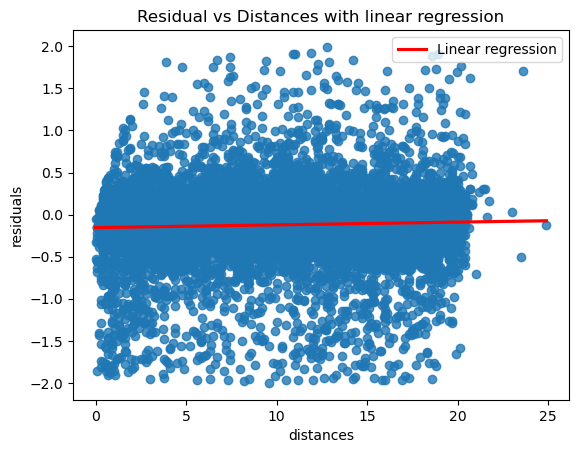

In [47]:
import pandas as pd
import numpy as np
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt

# Inspect the dataset and clear it
filename="residuals_261.npy"
df = pd.DataFrame(np.load(filename, allow_pickle=True).item())
cleared_df = df[np.abs(df["residuals"]) < 2]     # There are no negative distances

# Linear regression and plot
lin_reg = stats.linregress(cleared_df["distances"], cleared_df["residuals"])   # x: distances, y: residuals
print(f"---------SCIPY---------\nSlope: {lin_reg.slope}\nIntercept: {lin_reg.intercept}\n-----------------------")
sns.regplot(data=cleared_df, 
            x="distances", 
            y="residuals",
            line_kws={"color": "red", "label": "Linear regression"},
            scatter_kws={"label": "Data points"},
            )
plt.title("Residual vs Distances with linear regression")
plt.legend()
plt.show()